In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CatBoost

In [2]:
blocks = gpd.read_parquet('../data/traning_data/blocks_with_land_value_class.parquet')
blocks["land_use"] = blocks["land_use"].replace(
    [None, "None", "none", "NaN", "nan", "NULL", "null", ""],
    pd.NA
)
blocks = blocks[blocks["land_use"].notna()].copy()


blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
0,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,113.847998,942.386203,18.676889,6.849476,0.141792,0.440618,0.350797,0.066793,1,1.342591
1,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,145.884534,1952.414484,19.040968,7.577334,0.012638,0.107291,0.826455,0.053615,2,1.921047
2,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,148.543184,1507.223306,19.061421,7.318688,0.023362,0.107805,0.776600,0.092233,2,1.937704
3,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,132.691062,2197.747147,19.737919,7.695643,0.010342,0.200107,0.548507,0.241044,2,2.020252
4,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,99.160727,8603.688296,17.843517,9.060062,0.512695,0.456094,0.029580,0.001631,0,0.520147


In [17]:
target_col = "land_value_per_sqm"
num_cols = [c for c in blocks.columns if pd.api.types.is_numeric_dtype(blocks[c])]
corr_to_target = (
    blocks[num_cols]
    .corr(method="pearson")[target_col]
    .dropna()
    .sort_values(ascending=False)
)
display(corr_to_target)


land_value_per_sqm                1.000000
log_land_value_per_sqm            0.661068
fsi                               0.635098
gsi                               0.566516
l                                 0.467391
log_land_value                    0.436578
share_living                      0.379598
share_non_living                  0.371262
land_value                        0.365541
land_value_class_soft_expected    0.354777
land_value_class_pred             0.344653
residential                       0.338706
land_value_class_soft_3           0.328244
living_area                       0.266822
build_floor_area                  0.265002
mxi                               0.227459
population                        0.217532
non_living_area                   0.209964
footprint_area                    0.140766
land_value_class_soft_2           0.053161
business                          0.009801
share                            -0.034662
osr                              -0.047505
special    

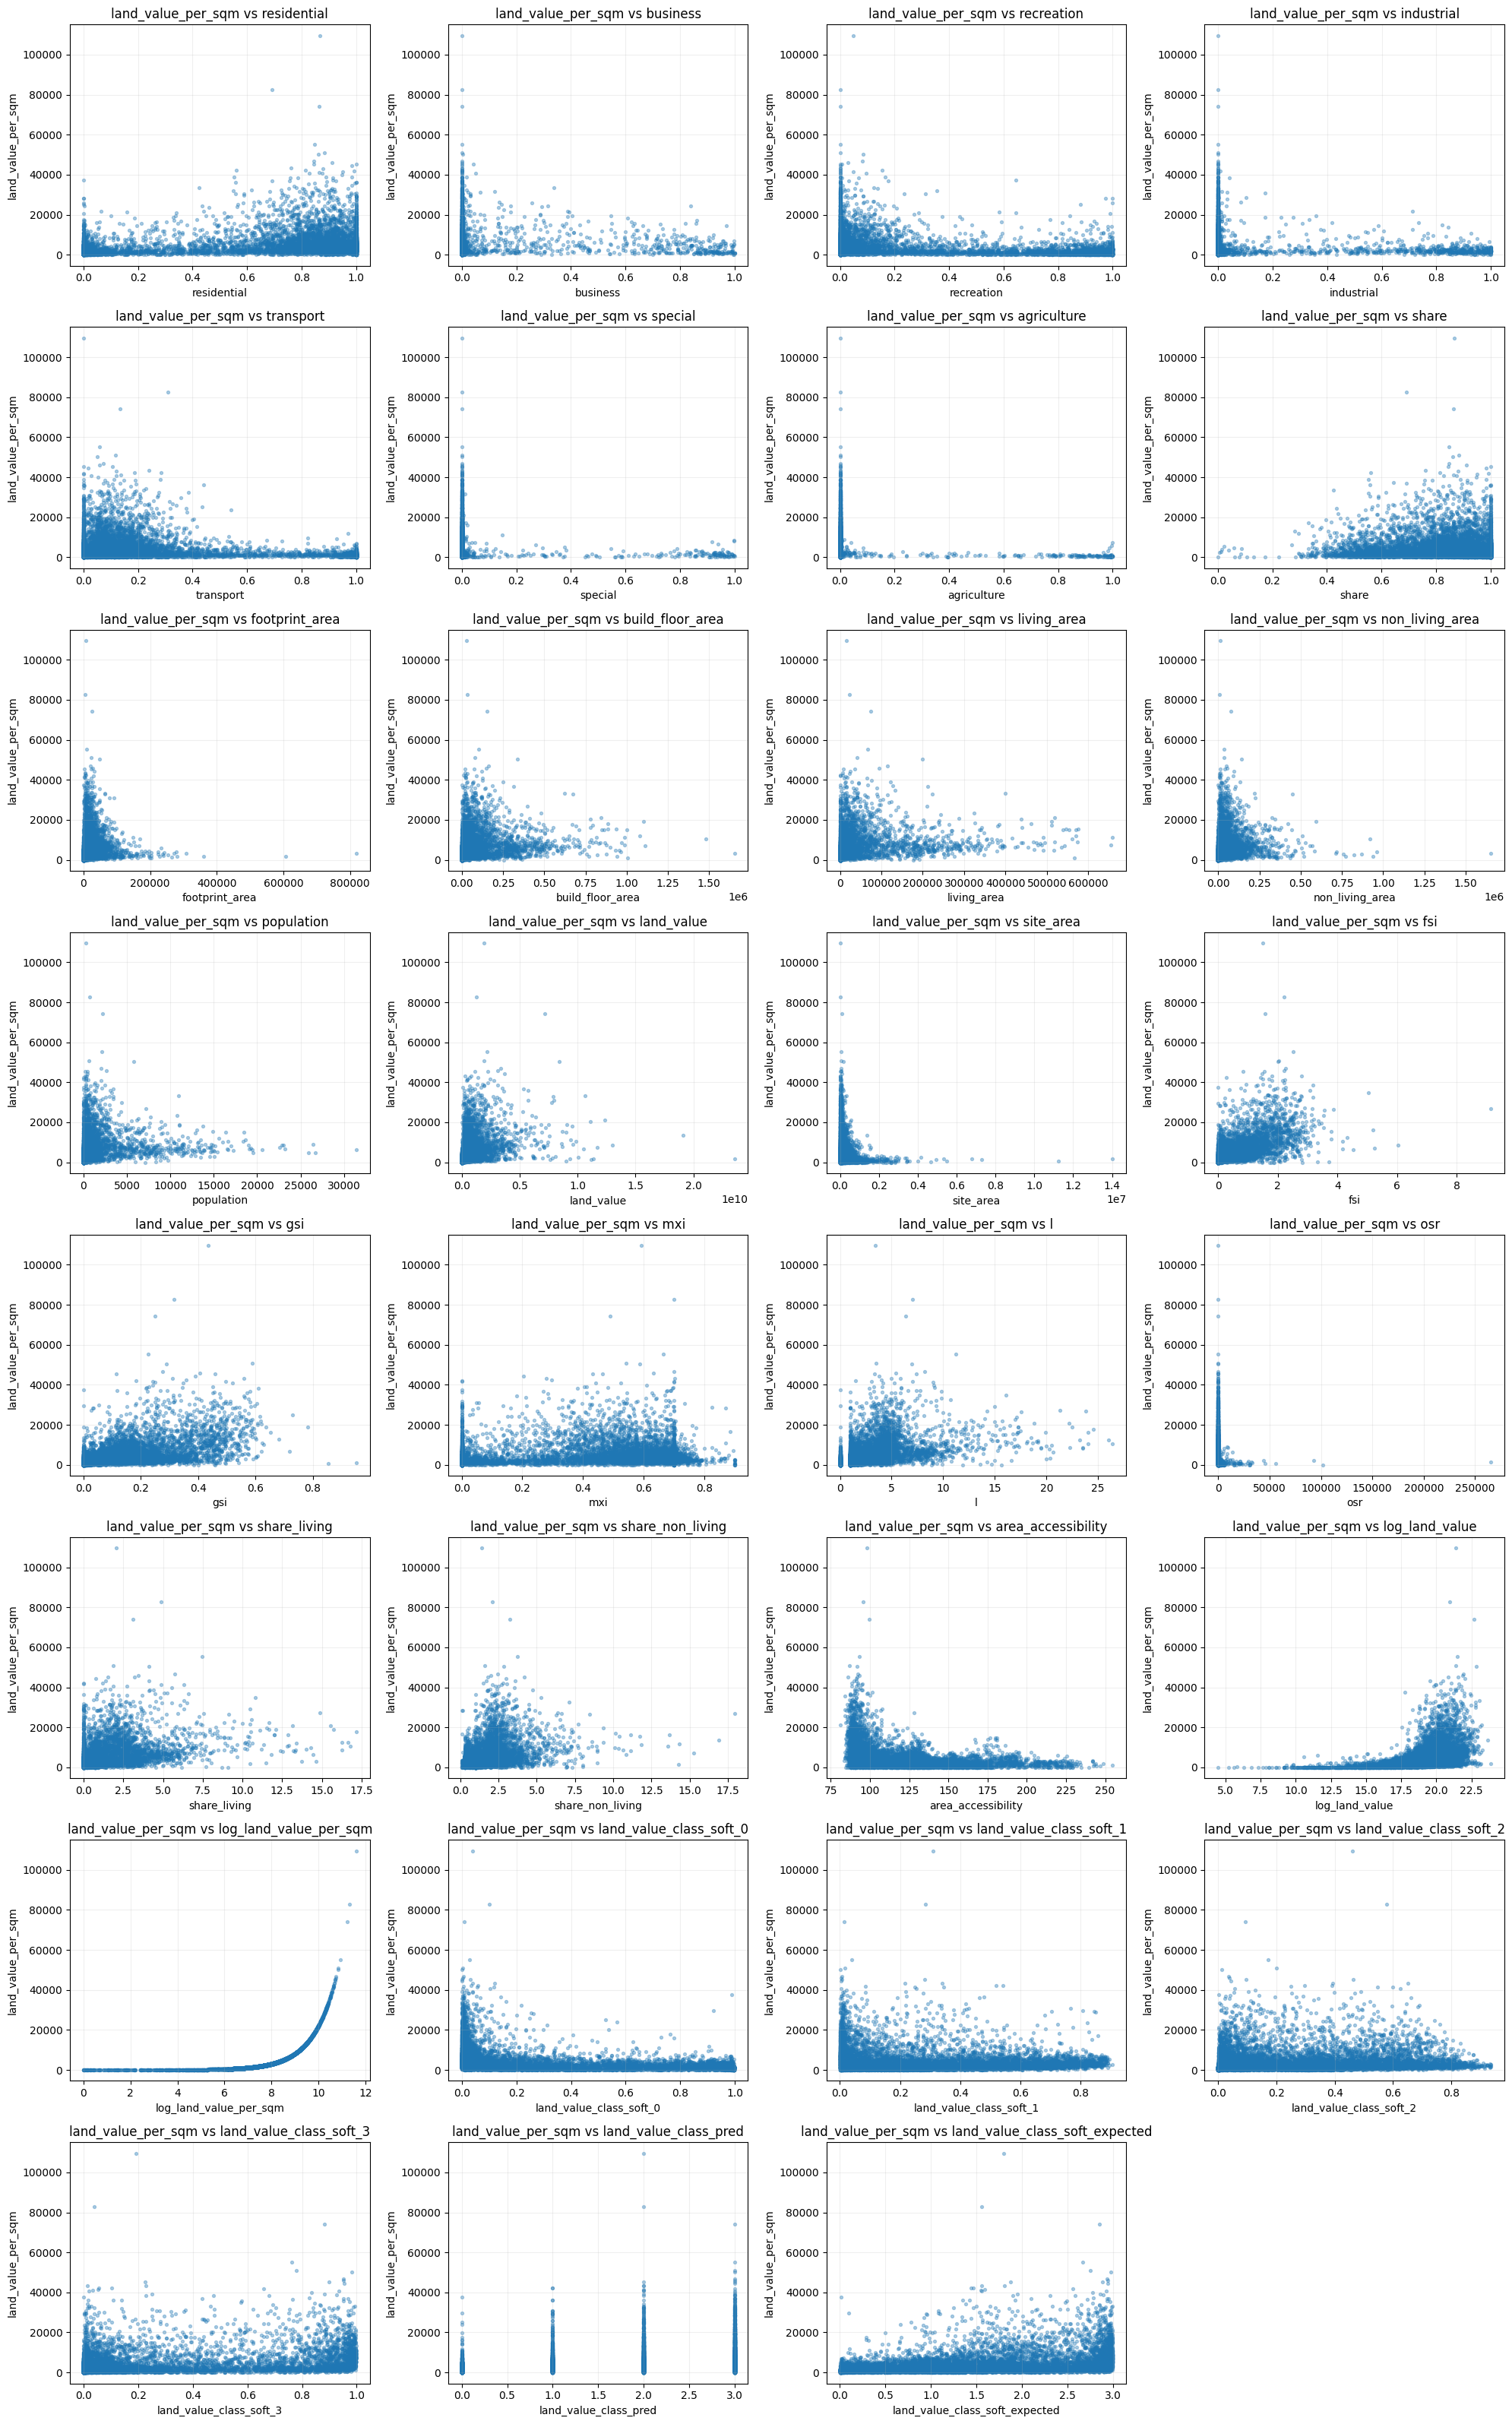

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Целевая переменная
target_col = "land_value_per_sqm"

# Берем все фичи кроме target и geometry
exclude = {target_col, "geometry"}
feature_cols = [c for c in blocks.columns if c not in exclude]

# Числовые фичи для scatter
num_features = [
    c for c in feature_cols
    if pd.api.types.is_numeric_dtype(blocks[c])
]

# Подготовка
n = len(num_features)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
axes = axes.flatten()

for i, col in enumerate(num_features):
    tmp = blocks[[col, target_col]].dropna()
    axes[i].scatter(tmp[col], tmp[target_col], s=8, alpha=0.35)
    axes[i].set_title(f"{target_col} vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_col)
    axes[i].grid(alpha=0.2)

# Удаляем пустые оси
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [23]:
blocks_with_large_errors = gpd.read_file("../data/traning_data/blocks_with_large_errors.geojson")
blocks_with_large_errors.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,lag2000_land_value_class_soft_expected,lag3000_land_value_class_soft_expected,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,land_value_pred,error_pct,geometry
0,0.0,0.000000,0.589514,0.0,0.000000,0.0,0.0,RECREATION,0.589514,0.000000,...,1.597935,1.351681,2,3,7,49,189,1.125203e+07,69503.130660,"POLYGON ((351332.407 6622228.557, 351334.384 6..."
1,0.0,0.000000,0.831374,0.0,0.000000,0.0,0.0,RECREATION,0.831374,0.000000,...,1.571028,1.364549,2,3,6,52,194,-7.112523e+06,2631.321113,"POLYGON ((351359.34 6622283.938, 351359.063 66..."
2,0.0,0.000000,0.882659,0.0,0.032277,0.0,0.0,RECREATION,0.882659,346.178070,...,0.999109,0.904263,0,0,3,85,214,-4.235730e+06,101.046801,"POLYGON ((331955.269 6661845.023, 331965.597 6..."
3,0.0,0.000411,0.897655,0.0,0.075606,0.0,0.0,RECREATION,0.897655,263.206093,...,1.835301,1.924933,1,4,14,76,172,3.671398e+07,2543.486845,"POLYGON ((347948.986 6659533.205, 347951.178 6..."
4,0.0,0.000188,0.999812,0.0,0.000000,0.0,0.0,RECREATION,0.999812,45.826443,...,1.025847,1.037357,0,0,4,34,133,7.808158e+08,262.268156,"POLYGON ((333059.258 6662638.042, 333088.351 6..."


(np.float64(300144.8701282337),
 np.float64(377601.7036858143),
 np.float64(6610306.8112260625),
 np.float64(6685949.201951948))

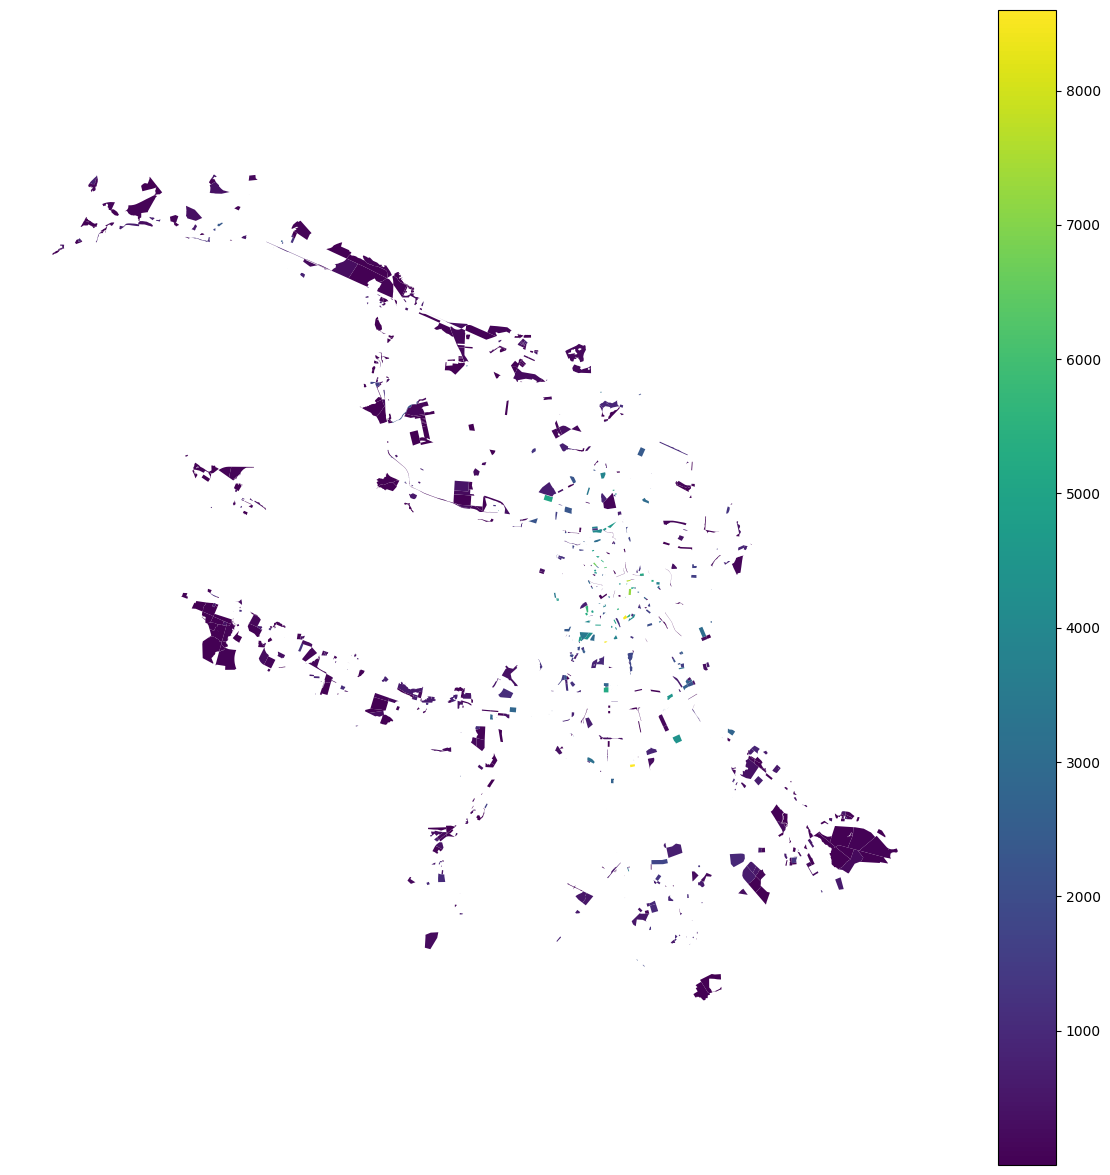

In [31]:
blocks_with_large_errors.plot(column="land_value_per_sqm", figsize=(15, 15), legend=True).axis("off")

In [24]:
blocks_with_error_over_60pct = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct.geojson")
blocks_with_error_over_60pct.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,pred_raw,land_value_pred,land_value_true,error_pct,geometry
0,0.000000,0.0,0.984579,0.0,0.000000,0.0,0.0,RECREATION,0.984579,585.487192,...,0,0,1,39,89,8.889784e+08,8.889784e+08,5.277053e+08,68.461149,"POLYGON ((339406.964 6666833.267, 339707.167 6..."
1,0.568247,0.0,0.288528,0.0,0.098242,0.0,0.0,RESIDENTIAL,0.568247,513.484777,...,1,3,9,44,68,5.687361e+07,5.687361e+07,3.369187e+07,68.805126,"POLYGON ((358575.218 6656798.193, 358572.41 66..."
2,0.000000,0.0,1.000000,0.0,0.000000,0.0,0.0,RECREATION,1.000000,475.554096,...,0,2,2,8,26,3.062602e+07,3.062602e+07,1.697712e+07,80.395863,"POLYGON ((334862.496 6663817.793, 334815.862 6..."
3,0.979315,0.0,0.000178,0.0,0.020507,0.0,0.0,RESIDENTIAL,0.979315,8696.240991,...,4,13,36,118,270,2.730839e+08,2.730839e+08,9.553385e+07,185.850442,"POLYGON ((347717.715 6643080.484, 347706.163 6..."
4,0.966722,0.0,0.000000,0.0,0.033278,0.0,0.0,RESIDENTIAL,0.966722,7423.965448,...,8,16,46,206,469,1.967152e+08,1.967152e+08,1.029906e+08,91.003089,"POLYGON ((351835.318 6645352.122, 351815.764 6..."


In [25]:
blocks_with_error_over_60pct2 = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct2.geojson")
blocks_with_error_over_60pct2.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,pred_raw,land_value_pred,land_value_true,error_pct,geometry
0,0.036769,0.049478,0.611127,0.0,0.301941,0.0,0.0,RECREATION,0.611127,225.914856,...,2,4,34,116,141,2.905371e+07,2.905371e+07,2.886810e+06,906.429650,"POLYGON ((331486.283 6665886.568, 331508.047 6..."
1,0.000000,0.000000,0.024514,0.0,0.975486,0.0,0.0,TRANSPORT,0.975486,0.000000,...,4,8,25,72,107,-9.688092e+05,-9.688092e+05,8.390276e+06,111.546810,"POLYGON ((330535.234 6667657.909, 330535.234 6..."
2,0.326325,0.000000,0.163653,0.0,0.498151,0.0,0.0,TRANSPORT,0.498151,2015.949680,...,3,9,27,53,84,1.458278e+08,1.458278e+08,8.995611e+07,62.109940,"POLYGON ((365623.978 6631240.154, 365626.905 6..."
3,0.844613,0.000000,0.036136,0.0,0.119251,0.0,0.0,RESIDENTIAL,0.844613,5335.847961,...,6,12,32,82,116,5.582991e+07,5.582991e+07,3.405182e+07,63.955737,"POLYGON ((365815.82 6625870.365, 365803.179 66..."
4,0.000000,0.000000,0.895150,0.0,0.104850,0.0,0.0,RECREATION,0.895150,0.000000,...,9,16,61,213,473,1.572839e+07,1.572839e+07,4.482206e+06,250.907204,"POLYGON ((351385.713 6647342.1, 351343.655 664..."


In [26]:
blocks_with_error_over_60pct3 = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct3.geojson")
blocks_with_error_over_60pct3.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,pred_raw,land_value_pred,land_value_true,error_pct,geometry
0,0.108342,0.000000,0.891658,0.0,0.000000,0.0,0.0,RECREATION,0.891658,0.000000,...,5,14,60,205,447,5.678058e+07,5.678058e+07,1.786907e+07,217.758932,"POLYGON ((351428.245 6647300.266, 351440.055 6..."
1,0.024715,0.072627,0.489266,0.0,0.413393,0.0,0.0,RECREATION,0.489266,161.467098,...,10,21,74,248,427,6.659308e+06,6.659308e+06,2.074318e+07,67.896405,"POLYGON ((348997.996 6646368.274, 348999.869 6..."
2,0.226151,0.590566,0.132126,0.0,0.051156,0.0,0.0,BUSINESS,0.590566,32311.556107,...,4,10,43,181,434,5.592216e+08,5.592216e+08,3.421804e+08,63.428892,"POLYGON ((351482.192 6648261.957, 351499.765 6..."
3,0.999419,0.000581,0.000000,0.0,0.000000,0.0,0.0,RESIDENTIAL,0.999419,8227.586617,...,3,9,33,82,185,2.868954e+08,2.868954e+08,1.712276e+08,67.552047,"POLYGON ((347126.83 6643214.39, 347135.632 664..."
4,0.763586,0.000000,0.000000,0.0,0.236414,0.0,0.0,RESIDENTIAL,0.763586,4099.369141,...,4,15,52,154,291,1.421954e+08,1.421954e+08,8.546343e+07,66.381611,"POLYGON ((353573.678 6646818.066, 353573.235 6..."


In [27]:
# старт
blocks_clean = blocks.copy()

# 1) удалить blocks_with_large_errors
tmp = blocks_with_large_errors
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# 2) удалить blocks_with_error_over_60pct
tmp = blocks_with_error_over_60pct
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# 3) удалить blocks_with_error_over_60pct2
tmp = blocks_with_error_over_60pct2
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# # 4) удалить blocks_with_error_over_60pct3
# tmp = blocks_with_error_over_60pct3
# if blocks_clean.crs != tmp.crs:
#     tmp = tmp.to_crs(blocks_clean.crs)
# bad_geom = set(tmp.geometry.to_wkb())
# blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

blocks_clean.head()



,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
0,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,113.847998,942.386203,18.676889,6.849476,0.141792,0.440618,0.350797,0.066793,1,1.342591
1,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,145.884534,1952.414484,19.040968,7.577334,0.012638,0.107291,0.826455,0.053615,2,1.921047
2,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,148.543184,1507.223306,19.061421,7.318688,0.023362,0.107805,0.776600,0.092233,2,1.937704
3,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,132.691062,2197.747147,19.737919,7.695643,0.010342,0.200107,0.548507,0.241044,2,2.020252
4,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,99.160727,8603.688296,17.843517,9.060062,0.512695,0.456094,0.029580,0.001631,0,0.520147


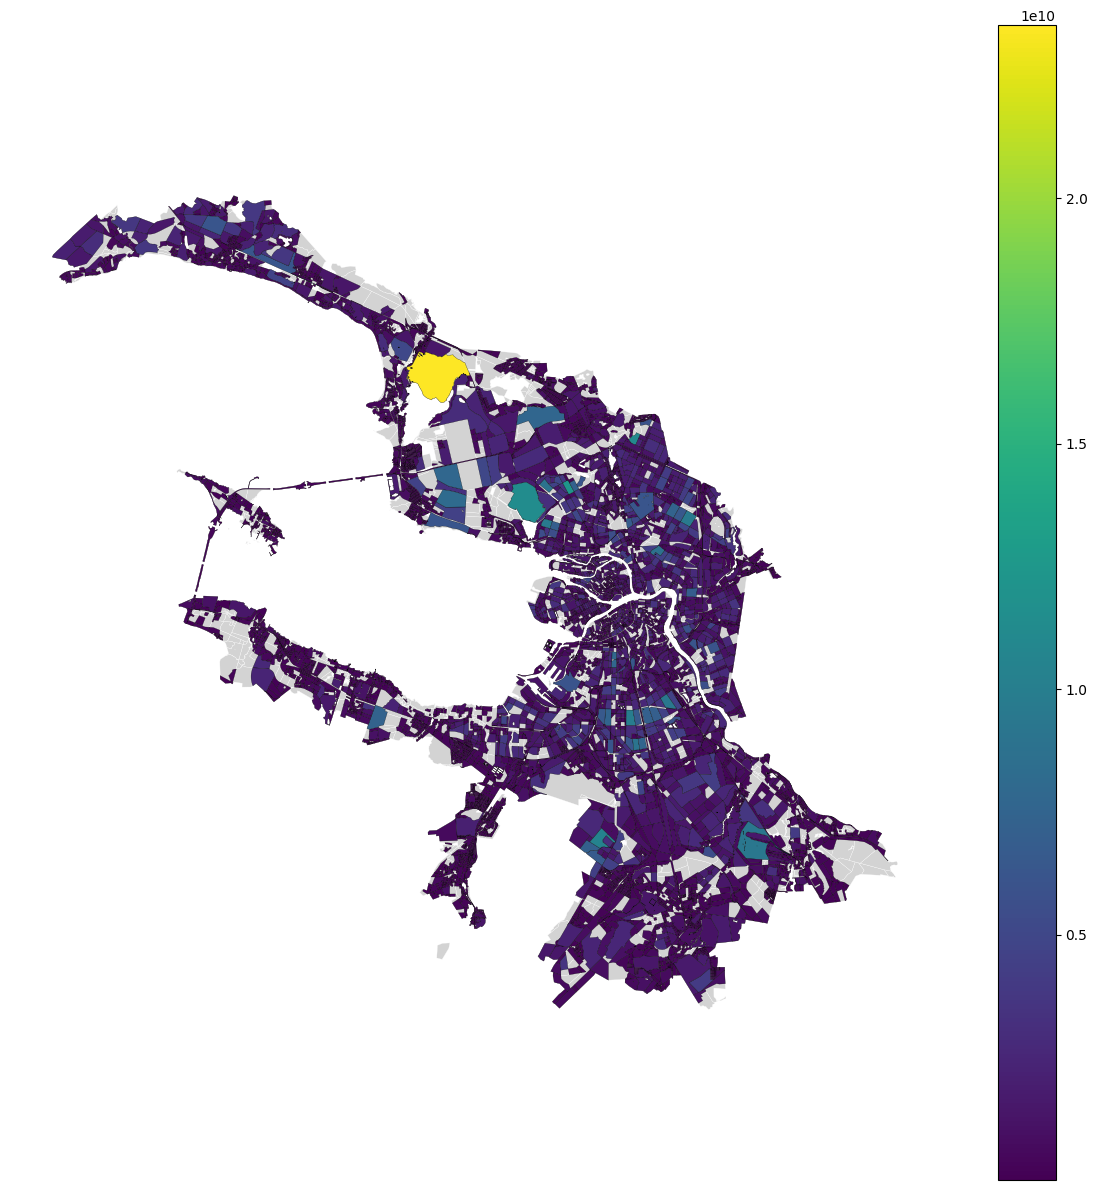

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 15))

# Все кварталы серым фоном
blocks.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.2)

# Отфильтрованные поверх с раскраской по land_value_per_sqm
blocks_clean.plot(
    ax=ax,
    column="land_value",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.2
)

ax.axis("off")
plt.show()

In [39]:
import pandas as pd

col = "land_use"

# Кол-во по land_use в blocks
cnt_blocks = (
    blocks[col]
    .value_counts(dropna=False)
    .rename("count_blocks")
)

# Кол-во по land_use в blocks_clean
cnt_blocks_clean = (
    blocks_clean[col]
    .value_counts(dropna=False)
    .rename("count_blocks_clean")
)

# Объединяем в одну таблицу
land_use_counts = (
    pd.concat([cnt_blocks, cnt_blocks_clean], axis=1)
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": col})
    .sort_values(col, na_position="last")
)

display(land_use_counts)


,land_use,count_blocks,count_blocks_clean
5,AGRICULTURE,142,115
4,BUSINESS,309,251
3,INDUSTRIAL,501,429
1,RECREATION,1671,982
0,RESIDENTIAL,4919,4072
6,SPECIAL,126,99
2,TRANSPORT,1049,747


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) выбери колонку цены (подставь свою)
col = "land_value" 

s = pd.to_numeric(blocks_clean[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

print("N:", len(s))
print("Mean:", s.mean())
print("Std:", s.std())
print("CV (std/mean):", s.std() / s.mean())
print("IQR:", s.quantile(0.75) - s.quantile(0.25))
print("Quantiles:\n", s.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))


N: 8717
Mean: 501887097.19076097
Std: 1026545006.5799261
CV (std/mean): 2.045370387734334
IQR: 435230303.8025267
Quantiles:
 0.01    1.077582e+05
0.05    4.992878e+06
0.25    5.487597e+07
0.50    1.589135e+08
0.75    4.901063e+08
0.95    2.160336e+09
0.99    4.733081e+09
Name: land_value, dtype: float64


# Тестовое обучение модели на всех данных (без фолдов). Цель - убедиться, что модель обучается и выдаёт адекватные метрики.

In [14]:
# === Simple train/test training (без фолдов) ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.metrics import r2_score
import numpy as np
from catboost import CatBoostRegressor, Pool
from urbanomy.methods.land_value_modeling.training_utils import (
    build_radii_weights,
    add_lags_full_df,
    feature_names,
    to_original_scale,
    mape,
    wape,
)

# 1) Настройки
target_col = "land_value_per_sqm"   # как в твоем ноутбуке
radius_list = [300, 500, 1000, 2000, 3000]
test_size = 0.2
seed = 42
use_services = False

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    # 'land_value_class_soft_0',
    # 'land_value_class_soft_1',
    # 'land_value_class_soft_2',
    # 'land_value_class_soft_3',
    # 'land_value_class_soft_4',
    # 'land_value_class_pred',
    "land_value_class_soft_expected",
}
cat_features = [c for c in ["land_use", "morphotype", ] if c in blocks_clean.columns]

def is_service_col(col: str) -> bool:
    return col.lower().startswith("count_")

# 2) Базовые признаки
feature_cols = []
for c in blocks_clean.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

# 3) Подготовка данных + lag-фичи на всем датасете
data_df = blocks_clean.copy()


for c in cat_features:
    data_df[c] = data_df[c].astype("string").fillna("missing")

numeric_feats = [c for c in feature_cols if c not in cat_features and c != target_col and c in data_df.columns]

weights = build_radii_weights(data_df, radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys([c for c in feature_cols if c in data_lag.columns] + cat_features))
feats = feature_names(data_lag, base_cols_for_model, target_col)

# 4) Один train/test split (без кросс-валидации)
idx_train, idx_test = train_test_split(
    data_lag.index,
    test_size=test_size,
    random_state=seed,
    shuffle=True,
)

df_train = data_lag.loc[idx_train].copy()
df_test = data_lag.loc[idx_test].copy()

train_pool = Pool(df_train[feats], label=df_train[target_col], cat_features=cat_features, feature_names=feats)
test_pool = Pool(df_test[feats], label=df_test[target_col], cat_features=cat_features, feature_names=feats)

# 5) Обучение
model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=20000,
    od_type="Iter",
    od_wait=500,
    random_seed=seed,
    verbose=200,
)

model.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=600,
    use_best_model=True,
)

# 6) Метрики на train и test в оригинальной шкале
# --- Train ---
y_train_pred_raw = np.asarray(model.predict(df_train[feats])).reshape(-1)
y_train_true_raw = df_train[target_col].to_numpy()

y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

train_mape = mape(y_train_true, y_train_pred)
train_wape = wape(y_train_true, y_train_pred)
train_r2 = r2_score(y_train_true, y_train_pred)
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

# --- Test ---
y_test_pred_raw = np.asarray(model.predict(df_test[feats])).reshape(-1)
y_test_true_raw = df_test[target_col].to_numpy()

y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

test_mape = mape(y_test_true, y_test_pred)
test_wape = wape(y_test_true, y_test_pred)
test_r2 = r2_score(y_test_true, y_test_pred)
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

print("Train metrics:")
print(f"MAPE: {train_mape:.6f} ({train_mape*100:.2f}%)")
print(f"WAPE: {train_wape:.6f} ({train_wape*100:.2f}%)")
print(f"MAE:  {train_mae:.6f}")
print(f"RMSE: {train_rmse:.6f}")
print(f"R2:   {train_r2:.6f}")

print("\nTest metrics:")
print(f"MAPE: {test_mape:.6f} ({test_mape*100:.2f}%)")
print(f"WAPE: {test_wape:.6f} ({test_wape*100:.2f}%)")
print(f"MAE:  {test_mae:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"R2:   {test_r2:.6f}")


Learning rate set to 0.011109
0:	learn: 5797.0185049	test: 6116.6312225	best: 6116.6312225 (0)	total: 6.2ms	remaining: 2m 3s
200:	learn: 3555.6952554	test: 4264.3038345	best: 4264.3038345 (200)	total: 1.16s	remaining: 1m 54s
400:	learn: 3176.6679502	test: 4058.9198381	best: 4058.9198381 (400)	total: 2.34s	remaining: 1m 54s
600:	learn: 2975.7028300	test: 3973.6949826	best: 3973.6949826 (600)	total: 3.48s	remaining: 1m 52s
800:	learn: 2806.9634688	test: 3920.3118481	best: 3920.2958606 (799)	total: 4.66s	remaining: 1m 51s
1000:	learn: 2643.3720901	test: 3881.7047052	best: 3881.7047052 (1000)	total: 5.83s	remaining: 1m 50s
1200:	learn: 2497.7424039	test: 3842.5848639	best: 3842.5848639 (1200)	total: 6.98s	remaining: 1m 49s
1400:	learn: 2367.3720301	test: 3810.5549339	best: 3810.5549339 (1400)	total: 8.15s	remaining: 1m 48s
1600:	learn: 2252.2503189	test: 3782.5932141	best: 3782.5932141 (1600)	total: 9.29s	remaining: 1m 46s
1800:	learn: 2150.8108986	test: 3760.1004064	best: 3760.0583451 (17

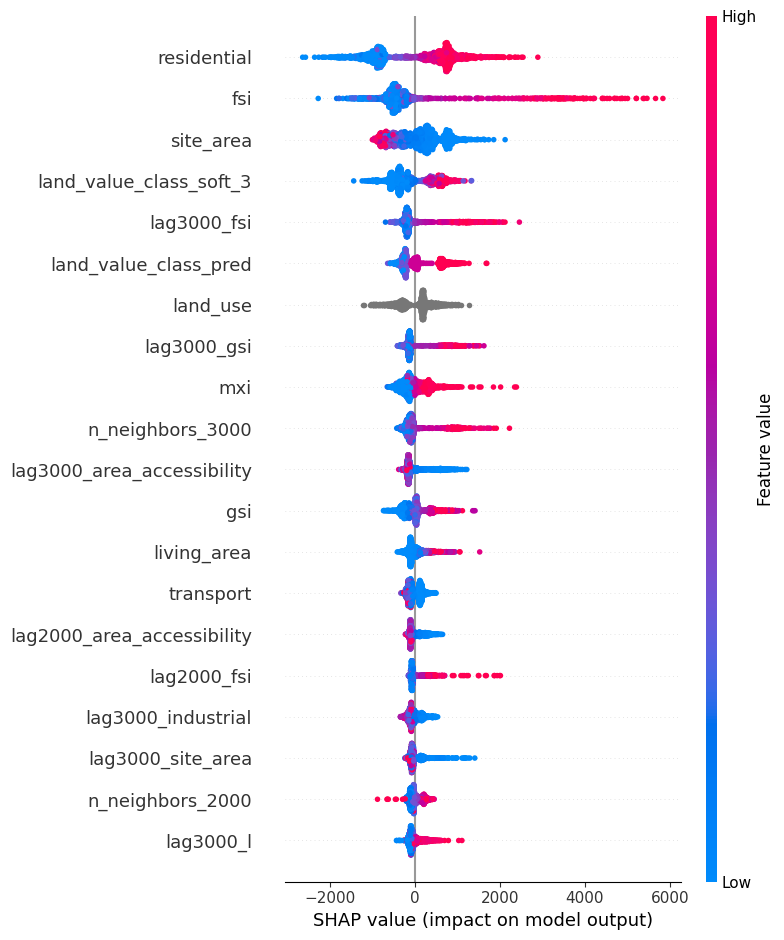

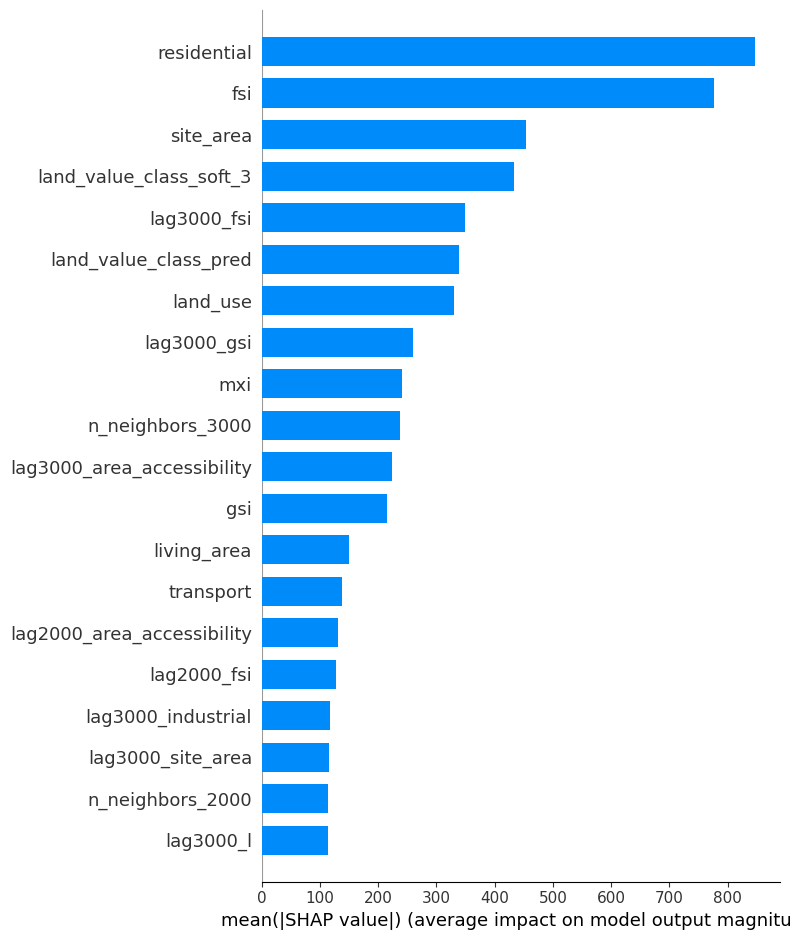

In [49]:
# === SHAP через shap: только 2 графика (beeswarm + bar) ===
import shap

X_test = df_test[feats]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 1) Beeswarm
shap.summary_plot(shap_values, X_test, feature_names=feats, show=True)

# 2) Bar (глобальная важность)
shap.summary_plot(shap_values, X_test, feature_names=feats, plot_type="bar", show=True)




In [28]:
numeric_feats

['residential',
 'business',
 'recreation',
 'industrial',
 'transport',
 'special',
 'agriculture',
 'share',
 'footprint_area',
 'build_floor_area',
 'living_area',
 'non_living_area',
 'population',
 'site_area',
 'fsi',
 'gsi',
 'mxi',
 'l',
 'area_accessibility',
 'land_value_class_soft_0',
 'land_value_class_soft_1',
 'land_value_class_soft_2',
 'land_value_class_soft_3',
 'land_value_class_pred']

In [84]:
# === Inference + метрики для land_value_per_sqm ===
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

from urbanomy.methods.land_value_modeling.training_utils import (
    prep_cat_inplace,
    build_radii_weights,
    add_lags_full_df,
)

# target теперь зафиксирован
target_col = "land_value_per_sqm"

# 1) Построить lag-фичи тем же способом, что на обучении
work_df = blocks_clean.copy()
prep_cat_inplace(work_df, cat_features)

weights_inf = build_radii_weights(work_df, radius_list)
data_lag_inf = add_lags_full_df(work_df, weights=weights_inf, numeric_cols=numeric_feats)

# 2) Проверка фичей
missing_feats = [c for c in feats if c not in data_lag_inf.columns]
if missing_feats:
    raise ValueError(
        f"Не хватает фичей для модели ({len(missing_feats)}): "
        f"{missing_feats[:20]}{' ...' if len(missing_feats) > 20 else ''}"
    )

# 3) Предсказание (raw -> original scale)
y_pred_raw = np.asarray(model.predict(data_lag_inf[feats])).reshape(-1)
y_pred = to_original_scale(y_pred_raw, target_col=target_col)

out_df = data_lag_inf.copy()
out_df["pred_raw"] = y_pred_raw
out_df["land_value_per_sqm_pred"] = y_pred

# 4) Метрики и error_pct
if target_col in out_df.columns:
    y_true_raw = out_df[target_col].to_numpy()
    y_true = to_original_scale(y_true_raw, target_col=target_col)

    out_df["land_value_per_sqm_true"] = y_true

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > 0)
    out_df["error_pct"] = np.nan
    out_df.loc[mask, "error_pct"] = (
        np.abs(y_pred[mask] - y_true[mask]) / np.abs(y_true[mask]) * 100.0
    )

    mape_val = mape(y_true[mask], y_pred[mask])   # доля
    wape_val = wape(y_true[mask], y_pred[mask])   # доля
    r2_val = r2_score(y_true[mask], y_pred[mask])

    print(f"Rows used in metrics: {mask.sum()} / {len(mask)}")
    print(f"MAPE: {mape_val:.6f} ({mape_val*100:.2f}%)")
    print(f"WAPE: {wape_val:.6f} ({wape_val*100:.2f}%)")
    print(f"R2:   {r2_val:.6f}")

    display(out_df[[target_col, "land_value_per_sqm_pred", "error_pct"]].head(20))

    out_df_over_10 = out_df[out_df["error_pct"] > 10].copy()
else:
    print(f"Column '{target_col}' not found -> predictions only.")
    display(out_df[["land_value_per_sqm_pred"]].head(20))


Rows used in metrics: 8717 / 8717
MAPE: 154.453850 (15445.38%)
WAPE: 0.137832 (13.78%)
R2:   0.918392


,land_value_per_sqm,land_value_per_sqm_pred,error_pct
0,942.39,"1,832.65",94.47
1,"1,952.41","1,903.80",2.49
2,"1,507.22","1,389.93",7.78
3,"2,197.75","2,345.01",6.70
4,"8,603.69","8,493.01",1.29
5,"1,421.13","1,205.04",15.21
6,557.20,576.37,3.44
7,751.03,789.49,5.12
8,"1,160.56","1,717.51",47.99
9,"3,325.54","3,480.75",4.67


In [85]:
out_df_over_10 = out_df[out_df["error_pct"] > 100]
out_df_20 = out_df[out_df["error_pct"] <= 100]


In [86]:
stats_by_landuse = (
    out_df_20
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        p90_error_pct=("error_pct", lambda s: s.quantile(0.90)),
        max_error_pct=("error_pct", "max"),
    )
    .sort_values("mean_error_pct", ascending=False)
)

display(stats_by_landuse)

,n,mean_error_pct,median_error_pct,p90_error_pct,max_error_pct
land_use,,,,,
AGRICULTURE,128,25.06,20.45,57.94,94.47
RECREATION,1315,23.44,16.51,55.14,99.54
SPECIAL,113,22.77,17.56,48.58,85.12
TRANSPORT,934,20.85,15.95,47.44,99.91
BUSINESS,292,17.35,10.46,39.38,98.38
INDUSTRIAL,477,16.02,9.97,35.40,91.33
RESIDENTIAL,4669,13.53,7.89,32.87,99.70


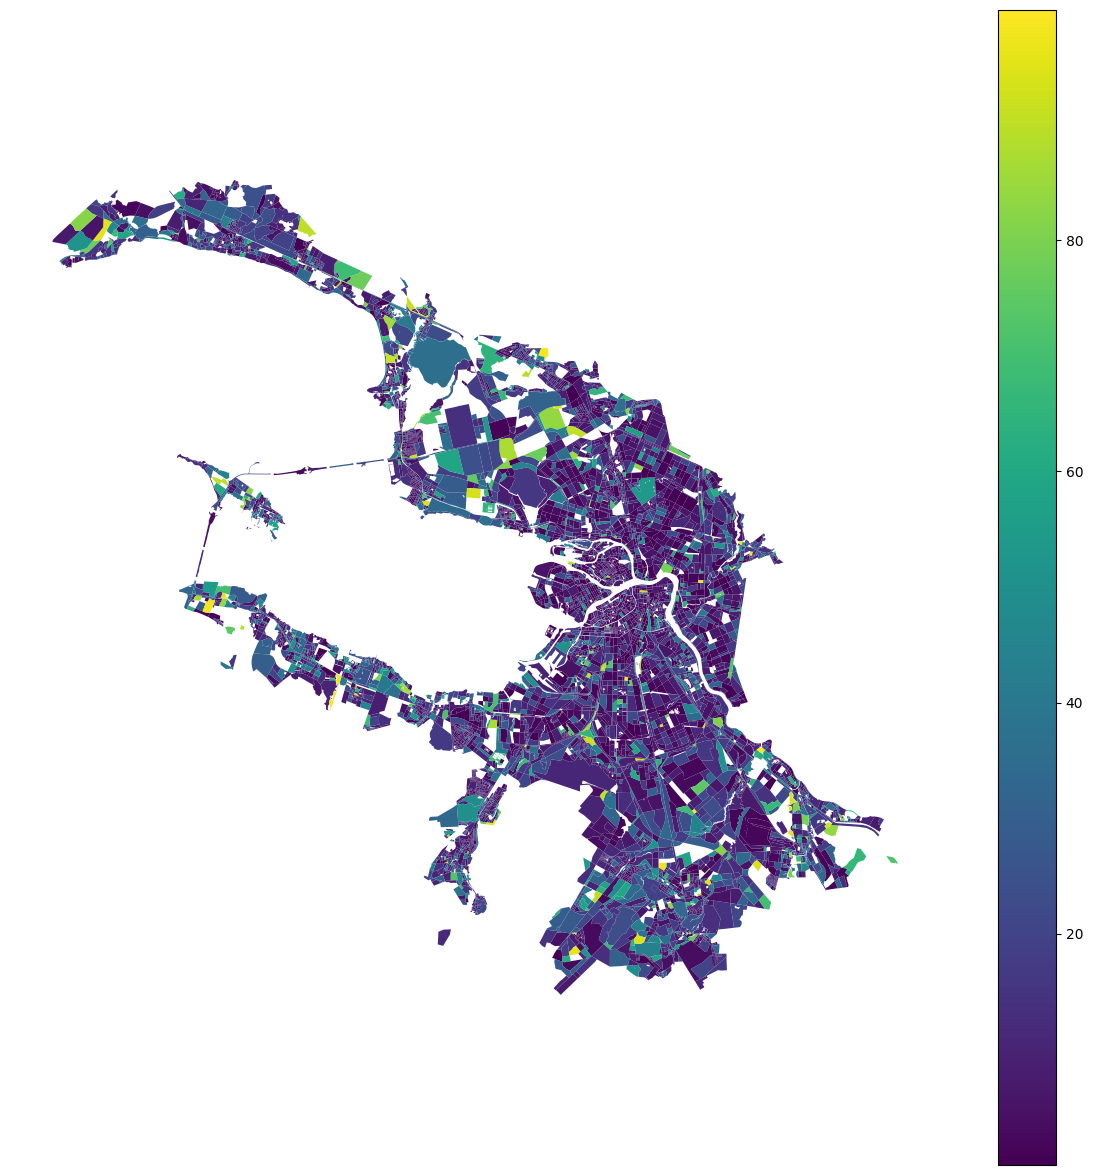

In [87]:
out_df_20.plot(
    column='error_pct',
    legend=True,
    figsize=(15,15),
    cmap='viridis'
).set_axis_off()

In [88]:
stats_by_landuse = (
    out_df_over_10
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        p90_error_pct=("error_pct", lambda s: s.quantile(0.90)),
        max_error_pct=("error_pct", "max"),
    )
    .sort_values("mean_error_pct", ascending=False)
)

display(stats_by_landuse)

,n,mean_error_pct,median_error_pct,p90_error_pct,max_error_pct
land_use,,,,,
TRANSPORT,115,"352,266.07",351.64,"10,828.10","39,953,812.31"
RECREATION,356,"235,276.01",522.30,"32,101.42","61,019,727.98"
INDUSTRIAL,24,"214,196.76",206.59,"1,876.49","5,129,194.03"
AGRICULTURE,14,"106,252.81",218.20,"104,109.16","1,334,618.86"
SPECIAL,13,"55,025.19",329.47,"17,699.63","677,664.23"
RESIDENTIAL,250,"11,562.83",207.92,"4,694.75","1,887,869.83"
BUSINESS,17,136.26,133.68,196.97,239.48


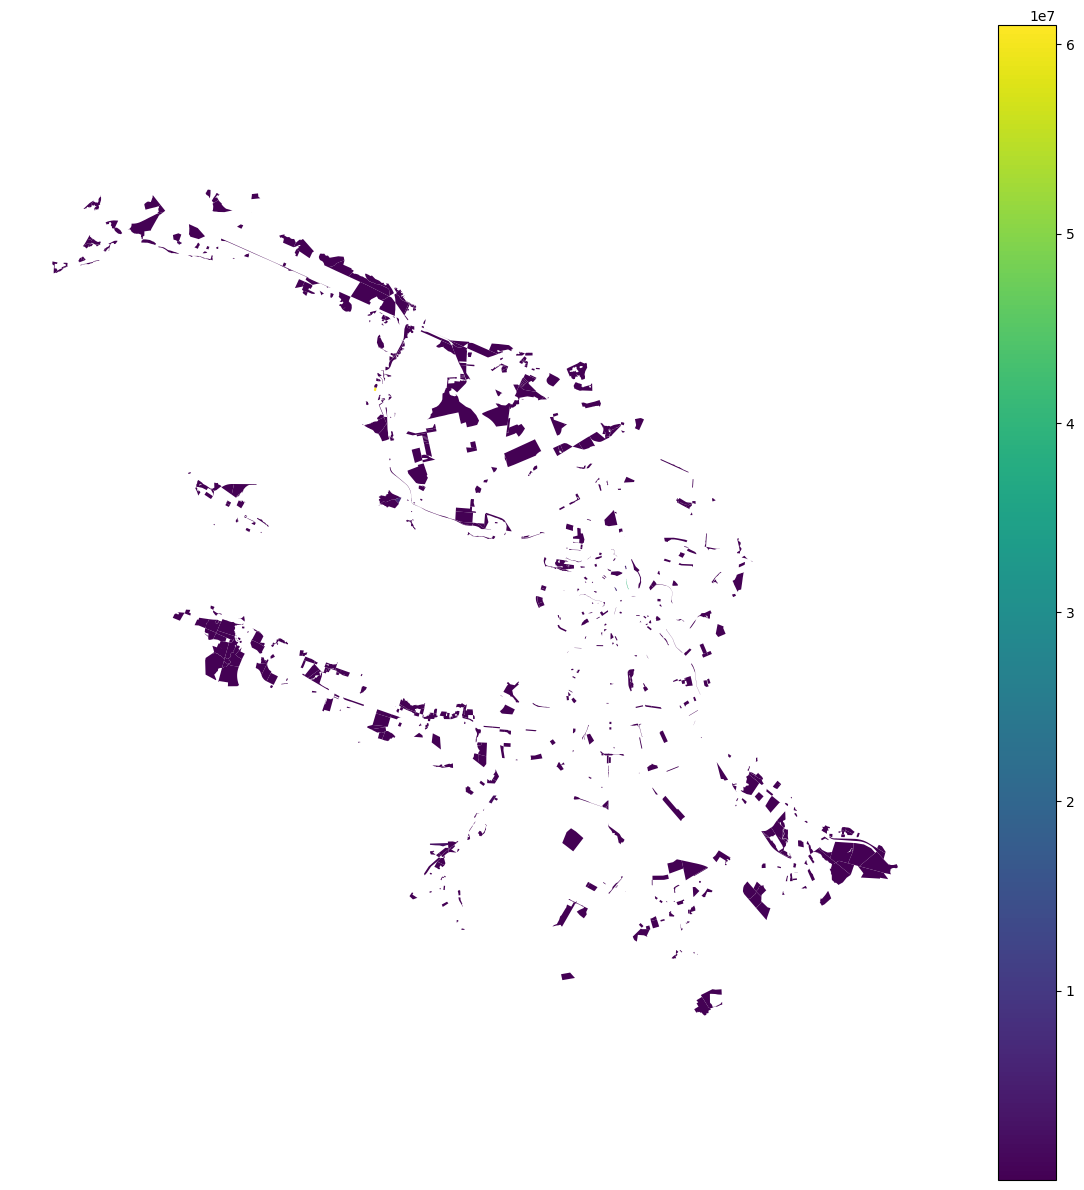

In [89]:
out_df_over_10.plot(
    column='error_pct',
    legend=True,
    figsize=(15,15),
    cmap='viridis'
).set_axis_off()

In [91]:
# === Conformal interval по land_use ===
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

alpha = 0.10  # 90% PI
group_col = "land_use"
true_col = "land_value_per_sqm_true"
pred_col = "land_value_per_sqm_pred"

# 1) валидные строки
valid_mask = (
    np.isfinite(out_df[true_col].to_numpy()) &
    np.isfinite(out_df[pred_col].to_numpy()) &
    out_df[group_col].notna()
)
df_valid = out_df.loc[valid_mask].copy()

# 2) calibration / evaluation
idx_cal, idx_eval = train_test_split(
    df_valid.index, test_size=0.5, random_state=42, shuffle=True
)
cal_df = df_valid.loc[idx_cal].copy()
eval_df = df_valid.loc[idx_eval].copy()

# 3) глобальный q_hat (fallback)
abs_err_cal_all = np.abs(cal_df[pred_col] - cal_df[true_col]).to_numpy()
n_all = len(abs_err_cal_all)
k_all = int(np.ceil((n_all + 1) * (1 - alpha)))
k_all = min(max(k_all, 1), n_all)
q_hat_global = np.partition(abs_err_cal_all, k_all - 1)[k_all - 1]

# 4) q_hat по группам land_use
min_cal_size = 30  # если в группе мало точек, используем глобальный q_hat
qhat_by_group = {}

for g, gdf in cal_df.groupby(group_col):
    abs_err = np.abs(gdf[pred_col] - gdf[true_col]).to_numpy()
    n = len(abs_err)
    if n < min_cal_size:
        qhat_by_group[g] = q_hat_global
        continue
    k = int(np.ceil((n + 1) * (1 - alpha)))
    k = min(max(k, 1), n)
    qhat_by_group[g] = np.partition(abs_err, k - 1)[k - 1]

# 5) строим интервалы
q_series = out_df[group_col].map(qhat_by_group).fillna(q_hat_global)
out_df["q_hat_land_use"] = q_series

out_df["pi_lower"] = (out_df[pred_col] - out_df["q_hat_land_use"]).clip(lower=0)
out_df["pi_upper"] = out_df[pred_col] + out_df["q_hat_land_use"]

# 6) оценка покрытия на eval
eval_tmp = out_df.loc[idx_eval].copy()
covered_eval = (eval_tmp[true_col] >= eval_tmp["pi_lower"]) & (eval_tmp[true_col] <= eval_tmp["pi_upper"])

coverage_eval_total = covered_eval.mean() * 100
avg_width_eval_total = (eval_tmp["pi_upper"] - eval_tmp["pi_lower"]).mean()

print(f"Target coverage: {(1-alpha)*100:.1f}%")
print(f"Empirical coverage (eval, total): {coverage_eval_total:.2f}%")
print(f"Average interval width (eval, total): {avg_width_eval_total:.2f}")

# покрытие по land_use
coverage_by_landuse = (
    eval_tmp.assign(covered=covered_eval)
    .groupby(group_col)
    .agg(
        n=("covered", "size"),
        coverage_pct=("covered", lambda s: s.mean() * 100),
        avg_width=("pi_upper", lambda s: (s - eval_tmp.loc[s.index, "pi_lower"]).mean()),
        q_hat=("q_hat_land_use", "mean"),
    )
    .sort_values("coverage_pct")
)

display(coverage_by_landuse)
display(out_df[[group_col, true_col, pred_col, "pi_lower", "pi_upper", "q_hat_land_use"]].head(20))


Target coverage: 90.0%
Empirical coverage (eval, total): 76.81%
Average interval width (eval, total): 1749.99


,n,coverage_pct,avg_width,q_hat
land_use,,,,
AGRICULTURE,69,66.67,671.21,339.17
BUSINESS,155,70.97,"1,602.51",810.66
SPECIAL,63,73.02,"1,003.33",513.22
RESIDENTIAL,2455,76.25,"2,040.62","1,022.25"
RECREATION,830,78.07,"1,582.19",844.13
INDUSTRIAL,244,78.69,"1,252.61",627.75
TRANSPORT,543,79.93,"1,181.78",602.14


,land_use,land_value_per_sqm_true,land_value_per_sqm_pred,pi_lower,pi_upper,q_hat_land_use
0,AGRICULTURE,942.39,"1,832.65","1,493.48","2,171.81",339.17
1,RESIDENTIAL,"1,952.41","1,903.80",881.55,"2,926.05","1,022.25"
2,RESIDENTIAL,"1,507.22","1,389.93",367.68,"2,412.19","1,022.25"
3,RESIDENTIAL,"2,197.75","2,345.01","1,322.76","3,367.26","1,022.25"
4,INDUSTRIAL,"8,603.69","8,493.01","7,865.26","9,120.76",627.75
5,AGRICULTURE,"1,421.13","1,205.04",865.87,"1,544.20",339.17
6,RECREATION,557.20,576.37,0.00,"1,420.50",844.13
7,RECREATION,751.03,789.49,0.00,"1,633.62",844.13
8,RESIDENTIAL,"1,160.56","1,717.51",695.26,"2,739.77","1,022.25"
9,RESIDENTIAL,"3,325.54","3,480.75","2,458.49","4,503.00","1,022.25"


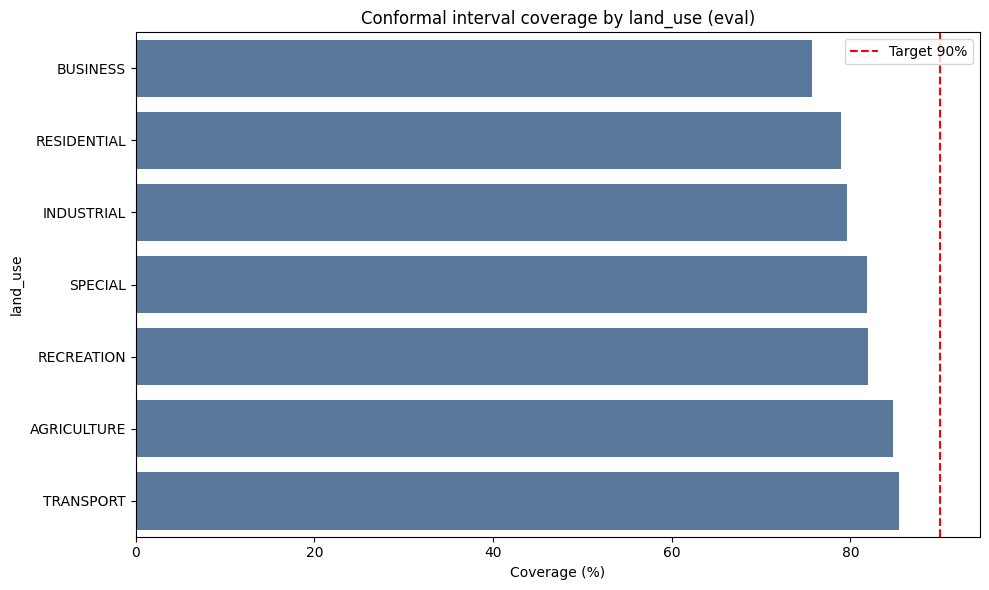

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

target_cov = (1 - alpha) * 100  # например 90%

plot_df = coverage_by_landuse.reset_index().copy()
plot_df = plot_df.sort_values("coverage_pct", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="coverage_pct", y=group_col, color="#4C78A8")
plt.axvline(target_cov, color="red", linestyle="--", label=f"Target {target_cov:.0f}%")
plt.xlabel("Coverage (%)")
plt.ylabel(group_col)
plt.title("Conformal interval coverage by land_use (eval)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# out_df_over_10.to_file("../data/blocks_with_error_over_100pct4.geojson", driver="GeoJSON")

# Основное обучение

In [ ]:
from urbanomy.methods.land_value_modeling.training_utils import TrainingConfig, run_training
import logging

# Флаг: учить с сервисами (count_*) или без
use_services = False   # False -> исключаем все count_* фичи

target_col = "land_value_per_sqm"
radius_list = [300, 500, 1000, 2000, 3000]

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    'land_value_class_soft_expected',
}

def is_service_col(col: str) -> bool:
    # сервисы у тебя обычно в формате count_...
    # если есть другие варианты (например Count_ / COUNT_), делаем lower()
    c = col.lower()
    return c.startswith("count_")

# формируем feature_cols с учетом флага
feature_cols = []
for c in blocks.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

cat_features = ["land_use", "morphotype", 'land_value_class_pred']

cfg = TrainingConfig(
    feature_cols=feature_cols,
    cat_features=cat_features,
    radius_list=radius_list,
    target_col=target_col,
    hpo_iter=24,
    n_clusters=15,
    inner_splits=5,
    outer_splits=5,
    iterations=20000,
    od_wait=500,
    seed=42,
)

model, metrics = run_training(
    blocks_clean,
    cfg,
    log_path=f"catboost_info/training_{'with_services' if use_services else 'no_services'}.log",
    console_level=logging.WARNING,
)

print("use_services =", use_services)
print(metrics)
 

OuterCV:   0%|          | 0/5 [00:00<?, ?it/s]

Trials:   0%|          | 0/24 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

...

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

InnerCV:   0%|          | 0/5 [00:00<?, ?it/s]

0:	learn: 3381.1776890	total: 4.73ms	remaining: 17.3s
200:	learn: 1638.1026370	total: 879ms	remaining: 15.2s
400:	learn: 1504.2103538	total: 1.72s	remaining: 14s
600:	learn: 1419.4431314	total: 2.57s	remaining: 13.1s
800:	learn: 1351.8561323	total: 3.44s	remaining: 12.3s
1000:	learn: 1295.3078652	total: 4.31s	remaining: 11.5s
1200:	learn: 1251.9571941	total: 5.17s	remaining: 10.6s
1400:	learn: 1216.0137967	total: 6.04s	remaining: 9.78s
1600:	learn: 1188.7456039	total: 6.9s	remaining: 8.91s
1800:	learn: 1163.8953514	total: 7.77s	remaining: 8.06s
2000:	learn: 1140.0934479	total: 8.63s	remaining: 7.19s
2200:	learn: 1119.6830971	total: 9.49s	remaining: 6.33s
2400:	learn: 1101.6223967	total: 10.4s	remaining: 5.5s
2600:	learn: 1084.9843217	total: 11.3s	remaining: 4.63s
2800:	learn: 1069.2625284	total: 12.2s	remaining: 3.79s
3000:	learn: 1052.6963981	total: 13.3s	remaining: 2.97s
3200:	learn: 1038.3009098	total: 14.2s	remaining: 2.08s
3400:	learn: 1024.8215853	total: 15.2s	remaining: 1.2s
360

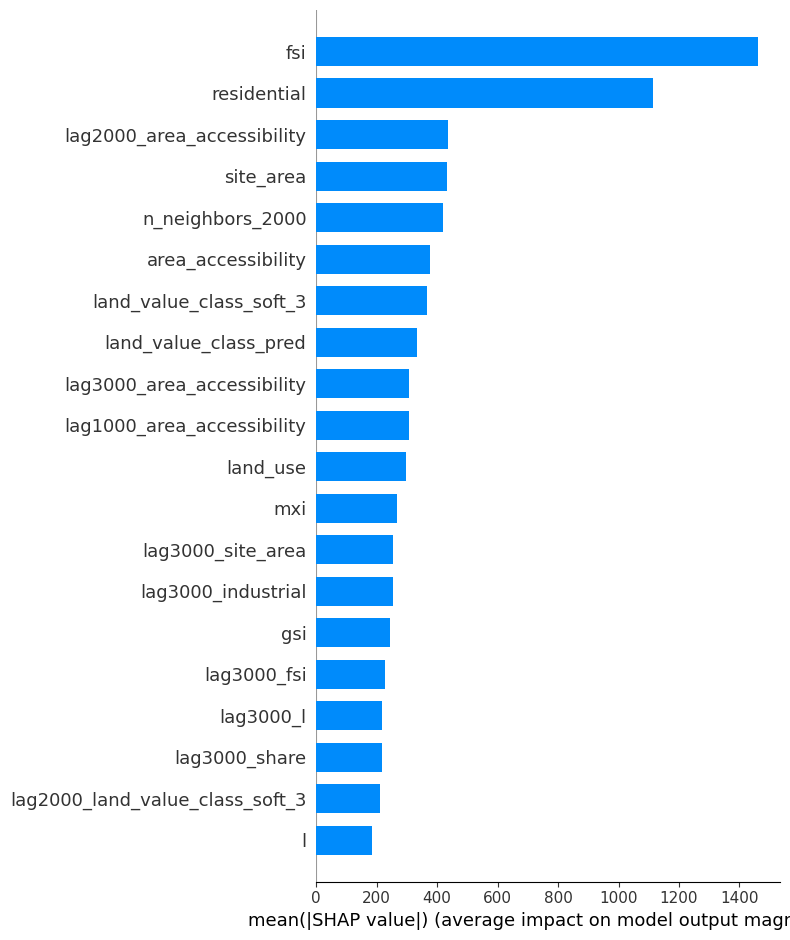

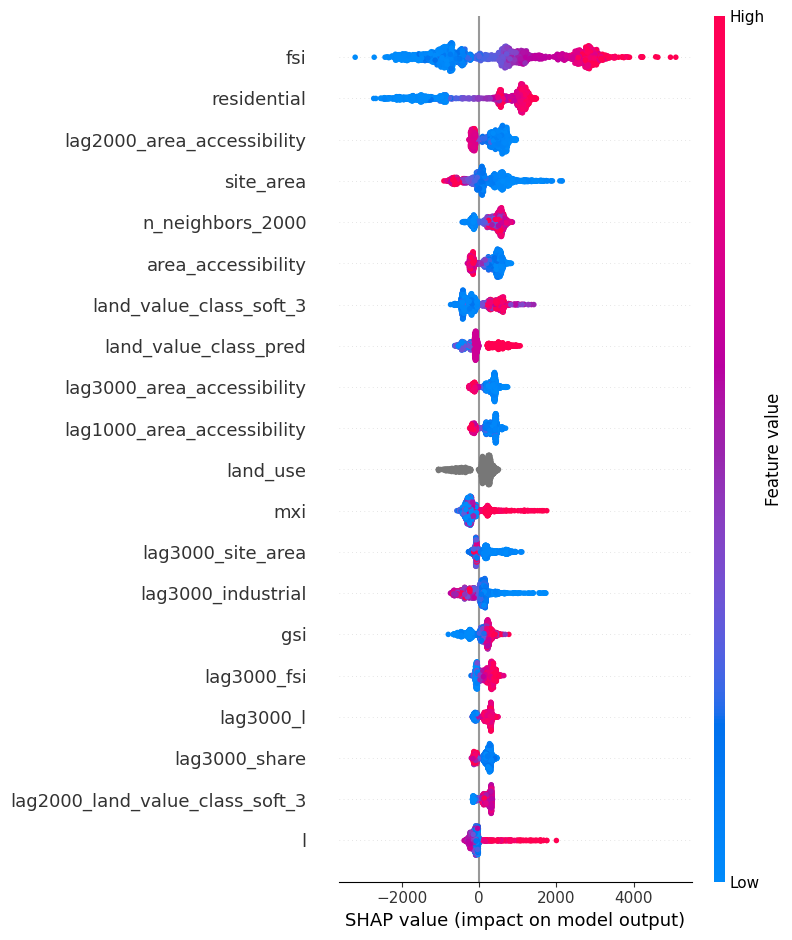

In [11]:
from catboost import Pool
from urbanomy.methods.land_value_modeling.training_utils import spatial_groups, build_radii_weights, add_lags_full_df, feature_names
from sklearn.model_selection import GroupKFold
import shap

# 1) same outer split as in training (pick first fold)
groups = spatial_groups(blocks, cfg.n_clusters, random_state=cfg.seed)
_, test_idx = list(GroupKFold(n_splits=cfg.outer_splits).split(blocks, blocks[target_col], groups))[0]
df_test = blocks.iloc[test_idx].copy()

# 2) compute lags on FULL dataset once (so test "sees" neighbors from all blocks),
# then slice out test rows
cat_features = list(cfg.cat_features)
numeric_feats = [c for c in cfg.feature_cols if c not in cat_features and c != target_col]

blocks_all = blocks.copy()
for c in cat_features:
    blocks_all[c] = blocks_all[c].astype("string").fillna("missing")

weights = build_radii_weights(blocks_all, cfg.radius_list)
blocks_lag = add_lags_full_df(blocks_all, weights=weights, numeric_cols=numeric_feats)

# 3) final feature list = base feature_cols + computed lag / n_neighbors cols
base_cols_for_model = list(dict.fromkeys(list(cfg.feature_cols) + cat_features))
feats = feature_names(blocks_lag, base_cols_for_model, target_col)

df_test_lag = blocks_lag.loc[df_test.index]

# 4) sample for SHAP
sample_df = df_test_lag[feats].sample(n=min(1500, len(df_test_lag)), random_state=42)
sample_pool = Pool(sample_df, cat_features=cat_features, feature_names=feats)

# 5) SHAP
explainer = shap.TreeExplainer(model)
shap_vals = explainer.shap_values(sample_pool, check_additivity=False)

shap.summary_plot(shap_vals, sample_df, plot_type="bar")
shap.summary_plot(shap_vals, sample_df)


In [12]:
# === Trust Report for WAPE: holdout + CI + baselines + segment stability ===
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GroupKFold

# ---------- helpers ----------
def to_original_scale(x, target_col: str):
    x = np.asarray(x)
    return np.expm1(x) if target_col.startswith("log_") else x

def wape(y_true, y_pred, eps: float = 1e-12):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(mask):
        return np.nan
    denom = np.sum(np.abs(y_true[mask]))
    if denom <= eps:
        return np.nan
    return np.sum(np.abs(y_true[mask] - y_pred[mask])) / denom

def bootstrap_wape_ci(y_true, y_pred, n_boot=2000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    vals = []
    idx_all = np.arange(n)
    for _ in range(n_boot):
        idx = rng.choice(idx_all, size=n, replace=True)
        vals.append(wape(y_true[idx], y_pred[idx]))
    vals = np.asarray(vals)
    return np.nanpercentile(vals, 100 * alpha / 2), np.nanpercentile(vals, 100 * (1 - alpha / 2))

# ---------- data ----------
data_df = blocks.copy()  # важно: используем blocks_clean
target_col = cfg.target_col
cat_features = [c for c in cfg.cat_features if c in data_df.columns]
numeric_feats = [c for c in cfg.feature_cols if c not in cat_features and c != target_col and c in data_df.columns]

for c in cat_features:
    data_df[c] = data_df[c].astype("string").fillna("missing")

weights = build_radii_weights(data_df, cfg.radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)
base_cols_for_model = list(dict.fromkeys([c for c in cfg.feature_cols if c in data_lag.columns] + cat_features))
feats = feature_names(data_lag, base_cols_for_model, target_col)

# ---------- holdout split (grouped) ----------
groups = spatial_groups(data_lag, cfg.n_clusters, random_state=cfg.seed)
train_idx, test_idx = list(GroupKFold(n_splits=cfg.outer_splits).split(data_lag, data_lag[target_col], groups))[0]

df_train = data_lag.iloc[train_idx].copy()
df_test = data_lag.iloc[test_idx].copy()

train_pool = Pool(df_train[feats], label=df_train[target_col], cat_features=cat_features, feature_names=feats)
test_pool = Pool(df_test[feats], label=df_test[target_col], cat_features=cat_features, feature_names=feats)

# ---------- point model (MAE) ----------
model_eval = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=max(cfg.iterations * 2, 3000),
    od_type="Iter",
    od_wait=cfg.od_wait,
    bootstrap_type="Bayesian",
    grow_policy="SymmetricTree",
    random_seed=cfg.seed,
    verbose=0,
)
model_eval.fit(train_pool, eval_set=test_pool, early_stopping_rounds=cfg.od_wait, use_best_model=True)

y_true = to_original_scale(df_test[target_col].to_numpy(), target_col)
y_pred = to_original_scale(model_eval.predict(df_test[feats]), target_col)

# ---------- main WAPE + CI ----------
wape_holdout = wape(y_true, y_pred)
wape_ci_low, wape_ci_high = bootstrap_wape_ci(y_true, y_pred, n_boot=2000, alpha=0.05, seed=cfg.seed)

# ---------- baselines ----------
# 1) global median baseline
train_target_orig = to_original_scale(df_train[target_col].to_numpy(), target_col)
pred_med = np.full_like(y_true, np.median(train_target_orig), dtype=float)
wape_med = wape(y_true, pred_med)

# 2) median by land_use baseline (если есть)
if "land_use" in df_train.columns and "land_use" in df_test.columns:
    med_by_land_use = (
        pd.DataFrame({"land_use": df_train["land_use"].astype("string"), "y": train_target_orig})
        .groupby("land_use")["y"].median()
    )
    global_med = float(np.median(train_target_orig))
    pred_lu = df_test["land_use"].astype("string").map(med_by_land_use).fillna(global_med).to_numpy(float)
    wape_lu = wape(y_true, pred_lu)
else:
    wape_lu = np.nan

# ---------- segment stability ----------
eval_df = df_test.copy()
eval_df["y_true"] = y_true
eval_df["y_pred"] = y_pred
eval_df["abs_err"] = np.abs(eval_df["y_true"] - eval_df["y_pred"])

# by land_use
if "land_use" in eval_df.columns:
    seg_land_use = (
        eval_df.groupby("land_use", dropna=False)
        .apply(lambda g: pd.Series({
            "n": len(g),
            "wape": np.sum(np.abs(g["y_true"] - g["y_pred"])) / np.sum(np.abs(g["y_true"])) if np.sum(np.abs(g["y_true"])) > 0 else np.nan
        }))
        .sort_values("wape")
    )
else:
    seg_land_use = pd.DataFrame()

# by y_true decile
eval_df["price_decile"] = pd.qcut(eval_df["y_true"], q=10, labels=False, duplicates="drop")
seg_decile = (
    eval_df.groupby("price_decile", dropna=False)
    .apply(lambda g: pd.Series({
        "n": len(g),
        "wape": np.sum(np.abs(g["y_true"] - g["y_pred"])) / np.sum(np.abs(g["y_true"])) if np.sum(np.abs(g["y_true"])) > 0 else np.nan
    }))
    .sort_index()
)

# ---------- report ----------
print("=== WAPE Trust Report ===")
if "metrics" in locals() and isinstance(metrics, dict) and "wape" in metrics:
    print(f"OOF CV WAPE: {metrics['wape']:.4f}  (std: {metrics.get('wape_std', np.nan):.4f})")
print(f"Holdout WAPE: {wape_holdout:.4f}")
print(f"Holdout WAPE 95% CI (bootstrap): [{wape_ci_low:.4f}, {wape_ci_high:.4f}]")
print(f"Baseline WAPE (global median): {wape_med:.4f}")
if np.isfinite(wape_lu):
    print(f"Baseline WAPE (median by land_use): {wape_lu:.4f}")

print("\nTop segments by land_use (lower WAPE is better):")
display(seg_land_use.head(15))

print("\nWAPE by price decile:")
display(seg_decile)


=== WAPE Trust Report ===
OOF CV WAPE: 34.7099  (std: 1.1984)
Holdout WAPE: 0.4705
Holdout WAPE 95% CI (bootstrap): [0.4543, 0.4865]
Baseline WAPE (global median): 0.8057
Baseline WAPE (median by land_use): 0.7609

Top segments by land_use (lower WAPE is better):


/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_16699/2774664744.py:107: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_16699/2774664744.py:120: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,n,wape
land_use,,
SPECIAL,10.00,0.26
INDUSTRIAL,74.00,0.38
BUSINESS,132.00,0.40
RESIDENTIAL,"1,155.00",0.46
TRANSPORT,182.00,0.51
AGRICULTURE,48.00,0.58
RECREATION,202.00,0.62



WAPE by price decile:


,n,wape
price_decile,,
0,181.00,2.34
1,180.00,0.71
2,180.00,0.51
3,180.00,0.47
4,181.00,0.46
5,180.00,0.33
6,180.00,0.25
7,180.00,0.29
8,180.00,0.45


In [11]:
# import json

# artifacts = {
#     "feature_cols": list(cfg.feature_cols),
#     "cat_features": list(cfg.cat_features),
#     "radius_list": list(cfg.radius_list),
#     "target_col": cfg.target_col,
#     "n_clusters": cfg.n_clusters,
#     "seed": cfg.seed,
# }

# with open("artifacts.json", "w") as f:
#     json.dump(artifacts, f, indent=2)

In [12]:
# with open("metrics.json", "w") as f:
#     json.dump(metrics, f, indent=2)

In [13]:


# model_path = "land_value_catboost_24_02_2026.cbm"
# model.save_model(model_path)

# print(f"Model saved to {model_path}")

In [14]:
# === Build lag features exactly for model inference + correct error metrics ===
import re
import numpy as np
import pandas as pd

from urbanomy.methods.land_value_modeling.training_utils import (
    prep_cat_inplace,
    build_radii_weights,
    add_lags_full_df,
)

# ---------------------------
# INPUTS (set these)
# ---------------------------
MODEL = model                  # trained CatBoost model
data_df = blocks_clean.copy()        # dataframe for prediction
target_col = "land_value_per_sqm"      # real target for error calc (if exists)
model_predicts_log1p = False   # True if model outputs log1p(target)

# ---------------------------
# 1) Feature schema from trained model
# ---------------------------
model_features = list(MODEL.feature_names_)

# radii used in lag-features (parsed from model feature names)
radii = sorted({
    int(m.group(1))
    for f in model_features
    for m in [re.match(r"lag(\d+)_", f), re.match(r"n_neighbors_(\d+)$", f)]
    if m is not None
})
if not radii:
    raise ValueError("No lag radii found in model.feature_names_ (no lag* / n_neighbors_* columns).")

# cat features: if cfg exists -> use it; else infer from current data + model base cols
if "cfg" in globals() and hasattr(cfg, "cat_features"):
    cat_features = [c for c in cfg.cat_features if c in data_df.columns]
else:
    lag_like = [c for c in model_features if c.startswith("lag") or c.startswith("n_neighbors_")]
    base_model_cols = [c for c in model_features if c not in lag_like]
    cat_features = [
        c for c in base_model_cols
        if c in data_df.columns and str(data_df[c].dtype) in ["object", "category", "string"]
    ]

# numeric base features for lag computation:
# use either cfg.feature_cols or infer from model features (exclude lag + neighbors + cats)
if "cfg" in globals() and hasattr(cfg, "feature_cols"):
    numeric_feats = [c for c in cfg.feature_cols if c not in cat_features and c in data_df.columns]
else:
    numeric_feats = []
    for f in model_features:
        if f.startswith("lag") or f.startswith("n_neighbors_"):
            continue
        if f in cat_features:
            continue
        if f in data_df.columns:
            numeric_feats.append(f)
    numeric_feats = list(dict.fromkeys(numeric_feats))

# ---------------------------
# 2) Build lag features on full dataframe (same logic as training utils)
# ---------------------------
work_df = data_df.copy()
prep_cat_inplace(work_df, cat_features)

weights = build_radii_weights(work_df, radii)
data_lag = add_lags_full_df(work_df, weights=weights, numeric_cols=numeric_feats)

# strict check: all model features must exist
missing = [f for f in model_features if f not in data_lag.columns]
if missing:
    raise ValueError(
        f"After lag build, model features are still missing ({len(missing)}): "
        f"{missing[:20]}{' ...' if len(missing) > 20 else ''}"
    )

# ---------------------------
# 3) Predict
# ---------------------------
X_pred = data_lag[model_features].copy()
y_pred = np.asarray(MODEL.predict(X_pred)).reshape(-1)
if model_predicts_log1p:
    y_pred = np.expm1(y_pred)

out_df = data_lag.copy()
out_df["land_value_pred"] = y_pred

# ---------------------------
# 4) Per-object error % + total MAPE/WAPE (in %)
# ---------------------------
if target_col in out_df.columns:
    y_true = out_df[target_col].astype(float).to_numpy()
    y_hat = out_df["land_value_pred"].astype(float).to_numpy()

    mask = np.isfinite(y_true) & np.isfinite(y_hat) & (y_true > 0)
    out_df["error_pct"] = np.nan
    out_df.loc[mask, "error_pct"] = (
        np.abs(y_hat[mask] - y_true[mask]) / np.abs(y_true[mask]) * 100.0
    )

    # MAPE (%)
    mape_pct = float(np.mean(np.abs((y_hat[mask] - y_true[mask]) / y_true[mask])) * 100.0)

    # WAPE (%): sum abs error / sum abs true
    wape_pct = float(
        np.sum(np.abs(y_hat[mask] - y_true[mask])) / np.sum(np.abs(y_true[mask])) * 100.0
    )

    print(f"Rows used in error metrics: {mask.sum()} / {len(mask)}")
    print(f"MAPE (%): {mape_pct:.4f}")
    print(f"WAPE (%): {wape_pct:.4f}")

    display(
        out_df[[target_col, "land_value_pred", "error_pct"]].head(20)
    )
else:
    print(f"Column '{target_col}' not found -> predictions only.")
    display(out_df[["land_value_pred"]].head(20))

# optional save
# blocks_with_lags_and_pred = out_df



Rows used in error metrics: 6695 / 6695
MAPE (%): 17.4432
WAPE (%): 19.0010


,land_value_per_sqm,land_value_pred,error_pct
0,942.39,"1,111.40",17.93
1,"1,952.41","2,054.10",5.21
2,"1,507.22","1,479.44",1.84
3,"2,197.75","2,245.09",2.15
4,"8,603.69","7,208.71",16.21
5,"1,421.13","1,247.15",12.24
8,"1,160.56","1,351.59",16.46
9,"3,325.54","3,386.37",1.83
10,"1,627.56","1,904.67",17.03
11,631.88,622.11,1.55


In [34]:
out_df_over_10 = out_df[out_df["error_pct"] > 100]
out_df_10 = out_df[out_df["error_pct"] <= 20]


In [35]:
out_df_over_10

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,lag3000_land_value_class_soft_expected,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,pred_raw,land_value_pred,land_value_true,error_pct
909,"POLYGON ((347282.729 6642511.974, 347286.506 6...",0.78,0.00,0.00,0.00,0.22,0.00,0.00,RESIDENTIAL,0.78,...,2.04,3,7,25,90,186,"158,794,323.66","158,794,323.66","36,703,109.44",332.65
951,"POLYGON ((357740.216 6621861.333, 357741.924 6...",0.53,0.00,0.00,0.00,0.47,0.00,0.00,RESIDENTIAL,0.53,...,1.34,2,3,16,66,109,"37,499,576.38","37,499,576.38","5,496,567.84",582.24
1030,"POLYGON ((352721.867 6647924.987, 352720.94 66...",0.91,0.00,0.03,0.00,0.06,0.00,0.00,RESIDENTIAL,0.91,...,2.07,5,15,55,190,363,"97,098,431.77","97,098,431.77","22,663,015.79",328.44
1044,"POLYGON ((338593.527 6629735.82, 338735.246 66...",0.00,0.00,0.00,0.00,1.00,0.00,0.00,TRANSPORT,1.00,...,0.62,8,20,42,124,228,"7,482,688.23","7,482,688.23","52,702.28","14,098.03"
1049,"POLYGON ((351674.494 6641933.253, 351724.921 6...",0.00,0.00,0.00,0.00,1.00,0.00,0.00,TRANSPORT,1.00,...,2.08,7,9,24,83,176,"-19,983,409.42","-19,983,409.42","42,377.59","47,255.60"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8692,"POLYGON ((337098.576 6639186.041, 337212.391 6...",0.92,0.00,0.03,0.00,0.03,0.00,0.00,RESIDENTIAL,0.92,...,1.26,3,11,24,64,174,"384,469,970.85","384,469,970.85","175,868,285.70",118.61
8695,"POLYGON ((338025.072 6639639.272, 337897.464 6...",0.00,0.00,0.08,0.00,0.00,0.00,0.00,RECREATION,0.08,...,1.62,0,3,13,43,97,"127,383,505.92","127,383,505.92","18,274,672.05",597.05
8697,"POLYGON ((337699.28 6638714.567, 337793.684 66...",0.00,0.00,0.76,0.00,0.24,0.00,0.00,RECREATION,0.76,...,1.38,1,4,26,72,183,"51,724,029.19","51,724,029.19","5,643,921.01",816.46
8706,"POLYGON ((333108.293 6639365.869, 333067.521 6...",1.00,0.00,0.00,0.00,0.00,0.00,0.00,RESIDENTIAL,1.00,...,1.10,3,6,26,93,153,"180,999,164.05","180,999,164.05","2,307,319.83","7,744.56"


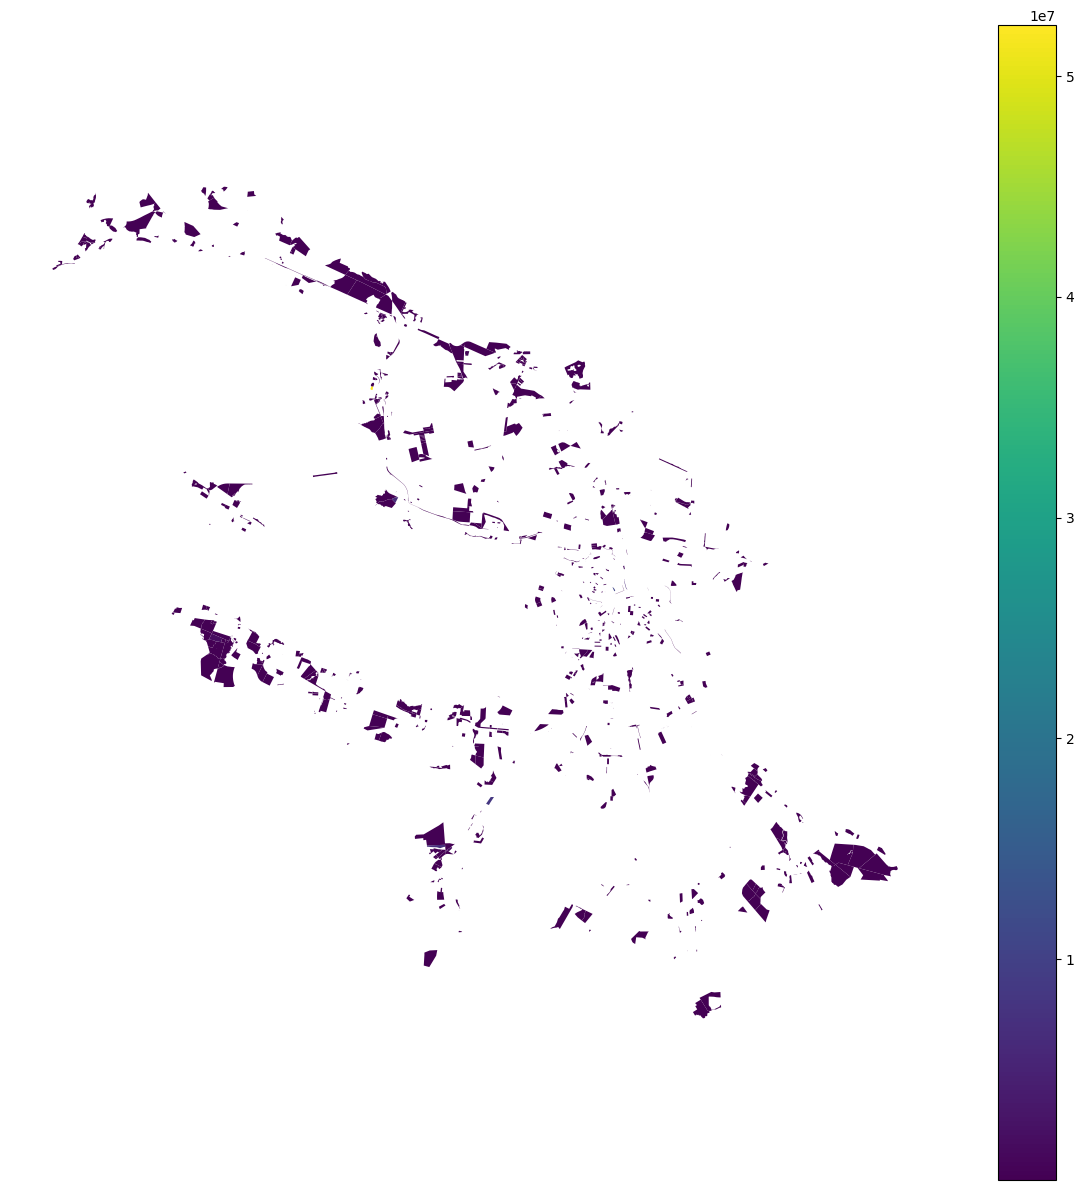

In [15]:
out_df_over_10.plot(
    column='error_pct',
    legend=True,
    figsize=(15,15),
    cmap='viridis'
).set_axis_off()

In [ ]:
# out_df_over_10.to_file("blocks_with_large_errors.geojson", driver="GeoJSON")

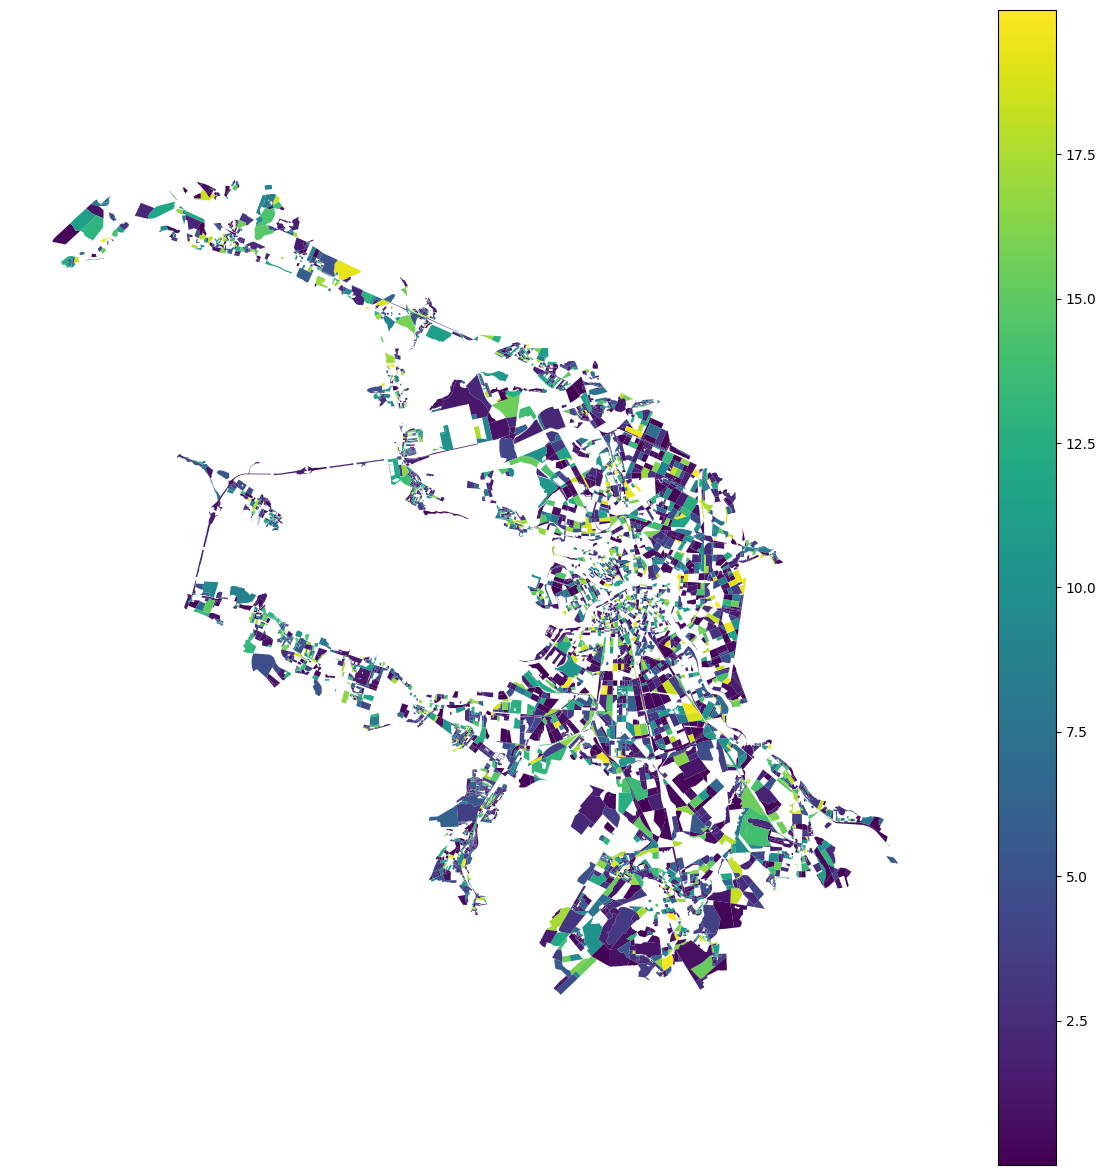

In [56]:
out_df_10.plot(
    column='error_pct',
    legend=True,
    figsize=(15,15),
    cmap='viridis'
).set_axis_off()

In [60]:
stats_by_landuse = (
    out_df_10
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        p90_error_pct=("error_pct", lambda s: s.quantile(0.90)),
        max_error_pct=("error_pct", "max"),
    )
    .sort_values("mean_error_pct", ascending=False)
)

display(stats_by_landuse)

,n,mean_error_pct,median_error_pct,p90_error_pct,max_error_pct
land_use,,,,,
None,1,15.53,15.53,15.53,15.53
RECREATION,666,7.29,5.73,17.01,19.98
RESIDENTIAL,3028,6.61,4.94,15.63,20.00
TRANSPORT,626,6.50,4.37,16.48,19.78
BUSINESS,207,6.26,4.09,16.14,19.50
INDUSTRIAL,342,5.52,3.06,15.55,19.72
SPECIAL,87,5.14,3.08,13.09,18.71
AGRICULTURE,96,4.96,2.55,13.43,19.71


In [14]:
stats_by_landuse = (
    out_df_over_10
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        p90_error_pct=("error_pct", lambda s: s.quantile(0.90)),
        max_error_pct=("error_pct", "max"),
    )
    .sort_values("mean_error_pct", ascending=False)
)

display(stats_by_landuse)


,n,mean_error_pct,median_error_pct,p90_error_pct,max_error_pct
land_use,,,,,
RECREATION,1212,"93,891.02",49.93,"1,201.13","84,310,288.73"
TRANSPORT,593,"58,857.30",33.50,302.06,"31,720,670.91"
SPECIAL,53,"18,423.76",32.98,769.42,"939,219.55"
AGRICULTURE,65,"14,553.91",31.74,305.19,"833,443.86"
INDUSTRIAL,236,"8,224.25",28.76,92.74,"1,912,309.00"
None,11,"4,687.63","2,662.91","8,187.56","23,942.43"
RESIDENTIAL,2750,"3,218.37",29.92,122.87,"7,576,368.29"
BUSINESS,157,43.51,25.56,82.04,530.33


In [ ]:
from urbanomy.methods.land_value_modeling.training_utils import to_original_scale, mape, wape
import numpy as np

# что было в обучении
print("cfg.target_col =", cfg.target_col)

# true/pred в той же шкале, что в fit:
# если модель обучалась на log_*, y_true_raw и y_pred_raw должны быть log-значениями
# и then to_original_scale сделает expm1
y_pred_raw = np.asarray(model.predict(X_pred)).reshape(-1)
y_true_raw = data_lag[cfg.target_col].to_numpy()   # ВАЖНО: тот же target_col, что в train

y_true_eval = to_original_scale(y_true_raw, target_col=cfg.target_col)
y_pred_eval = to_original_scale(y_pred_raw, target_col=cfg.target_col)

mape_ratio = mape(y_true_eval, y_pred_eval)   # 0.05 == 5%
wape_ratio = wape(y_true_eval, y_pred_eval)

print("MAPE ratio:", mape_ratio, "MAPE %:", mape_ratio * 100)
print("WAPE ratio:", wape_ratio, "WAPE %:", wape_ratio * 100)
